<a href="https://colab.research.google.com/github/surbhigarg45450-spec/algolab/blob/main/pepoledetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install torch torchvision --quiet
!pip install opencv-python-headless matplotlib numpy pillow tqdm scikit-learn --quiet
!pip install pycocotools datasets --quiet
print('✅ All dependencies installed!')

✅ All dependencies installed!


In [8]:
from datasets import load_dataset

ds = load_dataset("Chris1/cityscapes")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json:   0%|          | 0.00/864 [00:00<?, ?B/s]

data/train-00000-of-00014.parquet:   0%|          | 0.00/487M [00:00<?, ?B/s]

data/train-00001-of-00014.parquet:   0%|          | 0.00/521M [00:00<?, ?B/s]

data/train-00002-of-00014.parquet:   0%|          | 0.00/503M [00:00<?, ?B/s]

...

data/test-00005-of-00007.parquet:   0%|          | 0.00/499M [00:00<?, ?B/s]

data/test-00006-of-00007.parquet:   0%|          | 0.00/495M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2975 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1525 [00:00<?, ? examples/s]

In [9]:
import os, pathlib, shutil
import numpy as np
from PIL import Image

DATA_ROOT   = './foggy_cityscapes'
HF_DATASET  = 'Chris1/cityscapes'   # public, no login required
SUBSET_SIZE = {'train': 200, 'validation': 40}  # increase for a bigger run

# Cityscapes "person" appears under two possible pixel-value conventions
# depending on how a given segmentation export was encoded:
#   - raw labelIds convention: person = 24
#   - 19-class trainId convention: person = 11
# We don't assume which one this dataset uses -- we check both at runtime
# per-mask and use whichever actually has matching pixels (see
# extract_person_boxes_from_mask below). This avoids silently producing zero
# boxes if the convention differs from what we expect.
PERSON_LABEL_CANDIDATES = (24, 11)


def build_from_huggingface(data_root, hf_dataset=HF_DATASET, subset_size=SUBSET_SIZE):
    """
    IMPORTANT: this dataset is NOT natively streamable shard-by-shard -- it's an
    auto-converted-to-parquet repo, and `load_dataset(..., streaming=True)` on it
    still has to pull each ~500MB-1GB shard in full before yielding any rows from
    it. Asking for the whole 'train' split that way silently downloads all ~10GB
    across every shard (14 train + 3 val + 7 test), even if you only `.take(200)`.

    Fix: target exactly ONE shard per split directly via the `data_files`
    argument, using plain (non-streaming) loading. One shard is enough rows
    for our subset sizes below, and it caps the download at roughly
    500MB-1GB per split instead of ~10GB total.
    """
    from datasets import load_dataset
    from huggingface_hub import HfApi

    data_root = pathlib.Path(data_root)
    if data_root.exists():
        shutil.rmtree(data_root)

    api = HfApi()
    files = api.list_repo_files(hf_dataset, repo_type='dataset')

    split_map = {'train': 'train', 'val': 'validation'}
    for our_split, hf_split in split_map.items():
        # Find this split's shard filenames (e.g. 'data/train-00000-of-00014.parquet')
        # and grab only the first one.
        shard_candidates = sorted(
            f for f in files
            if f.startswith('data/') and f.endswith('.parquet') and f'{hf_split}-' in f
        )
        if not shard_candidates:
            raise FileNotFoundError(
                f"No parquet shards found for split '{hf_split}' in {hf_dataset}. "
                f"The repo layout may have changed -- check "
                f"https://huggingface.co/datasets/{hf_dataset}/tree/main/data"
            )
        first_shard = shard_candidates[0]
        print(f'⬇️  Loading 1 shard ({first_shard}) of {hf_dataset} [{hf_split}] '
              f'from Hugging Face (no login)...')

        # verification_mode='no_checks' is required here: the repo's recorded
        # dataset_infos.json declares the FULL split size (e.g. 2975 train rows
        # across all 14 shards), and `datasets` raises ExpectedMoreSplitsError /
        # NonMatchingSplitsSizesError if what we actually loaded (one shard) doesn't
        # match that recorded total. We're loading a partial shard on purpose, so we
        # skip that verification rather than disable it being the problem we set out
        # to avoid (downloading every shard just to satisfy the size check).
        ds = load_dataset(hf_dataset, data_files={hf_split: first_shard}, split=hf_split,
                           verification_mode='no_checks')

        img_dir = data_root / 'leftImg8bit' / our_split
        ann_dir = data_root / 'gtFine' / our_split
        img_dir.mkdir(parents=True, exist_ok=True)
        ann_dir.mkdir(parents=True, exist_ok=True)

        limit = min(subset_size.get(hf_split, subset_size.get(our_split, 200)), len(ds))
        n_saved = 0
        for i in range(limit):
            row = ds[i]
            img = row.get('image')
            mask = row.get('semantic_segmentation') or row.get('segmentation') or row.get('label')
            if img is None or mask is None:
                continue
            name = f'{our_split}_{i:05d}'
            img.convert('RGB').save(img_dir / f'{name}.png')
            mask.save(ann_dir / f'{name}_mask.png')
            n_saved += 1
        print(f'    saved {n_saved} real image+mask pairs to {img_dir}')

    return data_root


def extract_person_boxes_from_mask(mask_path, min_box_size=2):
    """
    Derive real person bounding boxes from a real semantic segmentation mask.
    Tries each known 'person' pixel-value convention and uses whichever one
    actually appears in this mask, so we don't silently return zero boxes
    if the dataset uses a different convention than expected.
    """
    mask = np.array(Image.open(mask_path))
    if mask.ndim == 3:
        mask = mask[..., 0]

    for person_id in PERSON_LABEL_CANDIDATES:
        ys, xs = np.where(mask == person_id)
        if len(xs) == 0:
            continue
        # Connected-component-free approximation: cluster into boxes via a
        # simple flood-fill over the binary person mask so multiple people
        # in one image become separate boxes instead of one giant box.
        binary = (mask == person_id).astype(np.uint8)
        boxes = _boxes_from_binary_mask(binary, min_box_size)
        if boxes:
            return boxes
    return []


def _boxes_from_binary_mask(binary, min_box_size=2):
    import cv2
    num_labels, labels = cv2.connectedComponents(binary, connectivity=8)
    boxes = []
    for label_id in range(1, num_labels):
        ys, xs = np.where(labels == label_id)
        if len(xs) == 0:
            continue
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()
        if (x2 - x1) >= min_box_size and (y2 - y1) >= min_box_size:
            boxes.append([float(x1), float(y1), float(x2), float(y2)])
    return boxes


if os.path.isdir(DATA_ROOT) and any(pathlib.Path(DATA_ROOT).rglob('*.png')):
    print(f"✅ Dataset already present at '{DATA_ROOT}', skipping download.")
else:
    build_from_huggingface(DATA_ROOT)
    n_images = sum(1 for _ in pathlib.Path(DATA_ROOT).rglob('*.png') if '_mask' not in _.name)
    print(f'✅ Dataset ready at {pathlib.Path(DATA_ROOT).resolve()}  ({n_images} real images)')

⬇️  Loading 1 shard (data/train-00000-of-00014.parquet) of Chris1/cityscapes [train] from Hugging Face (no login)...


Generating train split:   0%|          | 0/2975 [00:00<?, ? examples/s]

    saved 200 real image+mask pairs to foggy_cityscapes/leftImg8bit/train
⬇️  Loading 1 shard (data/validation-00000-of-00003.parquet) of Chris1/cityscapes [validation] from Hugging Face (no login)...


Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

    saved 40 real image+mask pairs to foggy_cityscapes/leftImg8bit/val
✅ Dataset ready at /content/foggy_cityscapes  (240 real images)


In [10]:
import os, json, warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from collections import defaultdict

warnings.filterwarnings('ignore')

CFG = {
    'DATA_ROOT'      : DATA_ROOT,  # set by the Section 1B download cell
    'BETA_LEVELS'    : [0.005, 0.01, 0.02],
    'NUM_CLASSES'    : 2,
    'BATCH_SIZE'     : 2,
    'NUM_EPOCHS'     : 10,
    'LR'             : 1e-4,
    'IMG_SIZE'       : (512, 1024),
    'SCORE_THRESH'   : 0.5,
    'DEVICE'         : 'cuda' if torch.cuda.is_available() else 'cpu',
    'DCP_PATCH_SIZE' : 15,
    'DCP_OMEGA'      : 0.95,
    'DCP_T0'         : 0.1,
    'BETA_SCORE_MAP' : {0.005: 1.0, 0.01: 0.9, 0.02: 0.75},
}

if not os.path.isdir(CFG['DATA_ROOT']):
    raise FileNotFoundError(
        f"Dataset not found at '{CFG['DATA_ROOT']}'. Run the Section 1B download cell first."
    )

print(f"✅ Dataset found at '{CFG['DATA_ROOT']}'.")
print(f"🖥️  Device : {CFG['DEVICE']}")
print(f"🔥 PyTorch: {torch.__version__}")

✅ Dataset found at './foggy_cityscapes'.
🖥️  Device : cuda
🔥 PyTorch: 2.11.0+cu128


In [11]:
class DarkChannelPriorDehazer:
    """Physics-based dehazing (He et al., CVPR 2009) used as detection preprocessing."""

    def __init__(self, patch_size=15, omega=0.95, t0=0.1):
        self.patch_size = patch_size
        self.omega = omega
        self.t0 = t0

    def dark_channel(self, img):
        min_ch = np.min(img, axis=2)
        k = cv2.getStructuringElement(cv2.MORPH_RECT, (self.patch_size, self.patch_size))
        return cv2.erode(min_ch, k)

    def atmospheric_light(self, img, dark):
        h, w = dark.shape
        n = max(1, h * w // 1000)
        idx = np.argpartition(dark.ravel(), -n)[-n:]
        rows, cols = np.unravel_index(idx, (h, w))
        return np.clip(img[rows, cols, :].max(axis=0), 0, 1)

    def transmission_map(self, img, A):
        norm = img / (A[None, None, :] + 1e-6)
        t = 1.0 - self.omega * self.dark_channel(norm)
        return np.clip(t, self.t0, 1.0)

    def guided_filter(self, guide, src, r=40, eps=1e-3):
        guide = guide.astype(np.float32)
        src = src.astype(np.float32)
        mI  = cv2.boxFilter(guide, -1, (r, r))
        mp  = cv2.boxFilter(src,   -1, (r, r))
        mIp = cv2.boxFilter(guide * src,   -1, (r, r))
        mII = cv2.boxFilter(guide * guide, -1, (r, r))
        a = (mIp - mI * mp) / (mII - mI * mI + eps)
        b = mp - a * mI
        return cv2.boxFilter(a, -1, (r, r)) * guide + cv2.boxFilter(b, -1, (r, r))

    def dehaze(self, img_bgr):
        """Main entry: uint8 BGR in, uint8 BGR out."""
        img  = img_bgr.astype(np.float32) / 255.0
        dark = self.dark_channel(img)
        A    = self.atmospheric_light(img, dark)
        t    = self.transmission_map(img, A)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        t    = self.guided_filter(gray, t)
        t3   = t[:, :, None]
        J    = (img - A[None, None, :]) / np.maximum(t3, self.t0) + A[None, None, :]
        return (np.clip(J, 0, 1) * 255).astype(np.uint8)


# ═══════════════════════════════════════════════════════════════════════════════
# NOVEL CONTRIBUTION 1 — Haze-Intensity-Aware Augmentation
# ═══════════════════════════════════════════════════════════════════════════════
class HazeIntensityAwareAugmentation:
    """Curriculum-ready haze synthesis: augmentation strength tied to beta level."""

    DIFFICULTY_BETA = {'easy': 0.005, 'medium': 0.010, 'hard': 0.020}

    def __init__(self, beta_range=(0.005, 0.025), A_range=(0.7, 1.0)):
        self.beta_range = beta_range
        self.A_range = A_range

    def add_haze(self, img_bgr, beta=None, depth_map=None):
        H, W = img_bgr.shape[:2]
        if beta is None:
            beta = np.random.uniform(*self.beta_range)
        if depth_map is None:
            depth_map = np.tile(np.linspace(0.5, 2.5, H)[:, None], (1, W))
        t = np.clip(np.exp(-beta * depth_map * 40), 0.05, 1.0)
        A = np.random.uniform(*self.A_range)
        J = img_bgr.astype(np.float32) / 255.0
        I = J * t[:, :, None] + A * (1 - t[:, :, None])
        return (np.clip(I, 0, 1) * 255).astype(np.uint8), beta, t

    def augment_with_curriculum(self, img_bgr, difficulty='medium'):
        beta = self.DIFFICULTY_BETA.get(difficulty, 0.010)
        beta = max(0.001, beta + np.random.uniform(-0.002, 0.002))
        return self.add_haze(img_bgr, beta=beta)


# ═══════════════════════════════════════════════════════════════════════════════
# NOVEL CONTRIBUTION 4 — Haze-Conditioned Confidence Adjuster
# ═══════════════════════════════════════════════════════════════════════════════
class HazeConditionedConfidenceAdjuster:
    """Post-NMS score scaling by fog density to reduce fog-induced false positives."""

    BETA_SCALE = {0.005: 1.00, 0.010: 0.90, 0.020: 0.75}

    def __init__(self, nms_iou=0.5, score_thresh=0.4):
        self.nms_iou = nms_iou
        self.score_thresh = score_thresh

    def _get_scale(self, beta):
        nearest = min(self.BETA_SCALE, key=lambda k: abs(k - beta))
        return self.BETA_SCALE[nearest]

    def adjust(self, detections, betas):
        out = []
        for det, beta in zip(detections, betas):
            scale  = self._get_scale(float(beta))
            scores = det['scores'] * scale
            keep   = scores >= self.score_thresh
            out.append({'boxes': det['boxes'][keep],
                        'scores': scores[keep],
                        'labels': det['labels'][keep]})
        return out


# ═══════════════════════════════════════════════════════════════════════════════
# NOVEL CONTRIBUTION 5 — FoggyCityscapesDataset (real photos + real masks,
# synthetic fog applied on load -- the same recipe the original Foggy
# Cityscapes paper uses: real Cityscapes photos + a fog simulation)
# ═══════════════════════════════════════════════════════════════════════════════
class FoggyCityscapesDataset(Dataset):
    """
    Expects the on-disk layout built by Section 1B (from the public,
    no-login Chris1/cityscapes Hugging Face dataset):
      <root>/leftImg8bit/{train,val}/<name>.png        real clean photo
      <root>/gtFine/{train,val}/<name>_mask.png         real segmentation mask

    Real person bounding boxes are derived from the real segmentation mask
    via extract_person_boxes_from_mask() (defined in Section 1B). Synthetic
    fog (Contribution 1) is then applied to the real photo at __getitem__
    time -- this mirrors how Sakaridis et al. built the actual Foggy
    Cityscapes dataset: real photos + a physically-motivated fog simulation.
    """

    def __init__(self, root, split='train', beta=0.01,
                 apply_dcp=True, apply_aug=True, img_size=(512, 1024)):
        self.root = root; self.split = split; self.beta = beta
        self.img_size = img_size
        self.dehazer  = DarkChannelPriorDehazer() if apply_dcp else None
        self.augmenter = HazeIntensityAwareAugmentation() if apply_aug else None
        self.has_annotations = True  # masks are always real here; see _parse_boxes
        self.samples  = self._collect()
        print(f'  [{split}] beta={beta} | samples={len(self.samples)} | '
              f'annotations={self.has_annotations} | DCP={apply_dcp} | Aug={apply_aug}')

    def _collect(self):
        img_dir = os.path.join(self.root, 'leftImg8bit', self.split)
        ann_dir = os.path.join(self.root, 'gtFine', self.split)
        samples = []
        if not os.path.isdir(img_dir):
            return samples
        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith('.png'):
                continue
            name = os.path.splitext(fname)[0]
            ann_path = os.path.join(ann_dir, f'{name}_mask.png')
            samples.append({
                'image': os.path.join(img_dir, fname),
                'ann': ann_path if os.path.isfile(ann_path) else None,
                'beta': self.beta,
            })
        return samples

    def _parse_boxes(self, ann_path):
        if ann_path is None or not os.path.isfile(ann_path):
            return []
        return extract_person_boxes_from_mask(ann_path)

    def _resize(self, img, boxes):
        H0, W0 = img.shape[:2]
        H1, W1 = self.img_size
        img = cv2.resize(img, (W1, H1))
        sx, sy = W1/W0, H1/H0
        return img, [[b[0]*sx, b[1]*sy, b[2]*sx, b[3]*sy] for b in boxes]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = cv2.imread(s['image'])  # real clean Cityscapes photo
        if img is None:
            raise FileNotFoundError(s['image'])
        boxes = self._parse_boxes(s['ann'])  # real boxes from real mask

        # Synthetic fog applied here (Contribution 1) -- this is the one
        # synthetic step in the pipeline, applied to a real photo, exactly
        # as the original Foggy Cityscapes dataset is constructed.
        if self.augmenter:
            diff = {0.005:'easy', 0.01:'medium', 0.02:'hard'}.get(self.beta, 'medium')
            img, _, _ = self.augmenter.augment_with_curriculum(img, diff)

        if self.dehazer:
            img = self.dehazer.dehaze(img)

        img, boxes = self._resize(img, boxes)
        img_t = T.ToTensor()(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if boxes:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels  = torch.ones(len(boxes), dtype=torch.int64)
        else:
            boxes_t = torch.zeros((0,4), dtype=torch.float32)
            labels  = torch.zeros(0, dtype=torch.int64)
        return img_t, {'boxes': boxes_t, 'labels': labels,
                       'beta': torch.tensor(s['beta'], dtype=torch.float32),
                       'image_id': torch.tensor(idx)}


# ═══════════════════════════════════════════════════════════════════════════════
# NOVEL CONTRIBUTION 2 — Multi-Task Haze Estimation Head
# ═══════════════════════════════════════════════════════════════════════════════
class HazeEstimationHead(nn.Module):
    """Auxiliary branch predicting beta from FPN features shared with the detector."""

    def __init__(self, in_channels=256, hidden=128):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.net  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels * 16, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, 1),
            nn.Sigmoid(),
        )
        self.beta_scale = 0.025

    def forward(self, features):
        x = list(features.values())[-2]
        return (self.net(self.pool(x)) * self.beta_scale).squeeze(1)


class HazeAwareFasterRCNN(nn.Module):
    """Faster R-CNN extended with HazeEstimationHead (Novel Contribution 2)."""

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        w = FasterRCNN_ResNet50_FPN_Weights.DEFAULT if pretrained else None
        self.detector = fasterrcnn_resnet50_fpn(weights=w)
        in_f = self.detector.roi_heads.box_predictor.cls_score.in_features
        self.detector.roi_heads.box_predictor = FastRCNNPredictor(in_f, num_classes)
        self.haze_head = HazeEstimationHead()

    def forward(self, images, targets=None):
        if self.training:
            features  = self.detector.backbone(images.tensors)
            beta_pred = self.haze_head(features)
            beta_gt   = torch.stack([t['beta'] for t in targets]).to(beta_pred.device)
            losses    = self.detector(images, targets)
            losses['loss_haze'] = F.mse_loss(beta_pred, beta_gt) * 10.0
            return losses
        return self.detector(images, targets)


# ═══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════════════════════
def collate_fn(batch):
    return tuple(zip(*batch))


def get_sample_image(cfg, beta=0.01, index=0):
    """
    Loads one real image from the actual downloaded dataset (no synthetic
    generation). Used by the visualisation sections below as a real-data
    stand-in wherever the previous version used a fabricated scene.
    """
    ds = FoggyCityscapesDataset(cfg['DATA_ROOT'], split='train', beta=beta,
                                 apply_dcp=False, apply_aug=False, img_size=cfg['IMG_SIZE'])
    if len(ds) == 0:
        raise FileNotFoundError(
            f"No images found under {cfg['DATA_ROOT']}. Re-run the Section 1B download cell."
        )
    sample = ds.samples[index % len(ds.samples)]
    img = cv2.imread(sample['image'])
    boxes = ds._parse_boxes(sample['ann'])
    return img, boxes, ds.has_annotations


print('✅ All classes defined: DarkChannelPriorDehazer, HazeIntensityAwareAugmentation,')
print('   HazeConditionedConfidenceAdjuster, FoggyCityscapesDataset, HazeAwareFasterRCNN')

✅ All classes defined: DarkChannelPriorDehazer, HazeIntensityAwareAugmentation,
   HazeConditionedConfidenceAdjuster, FoggyCityscapesDataset, HazeAwareFasterRCNN


  [train] beta=0.01 | samples=200 | annotations=True | DCP=False | Aug=False


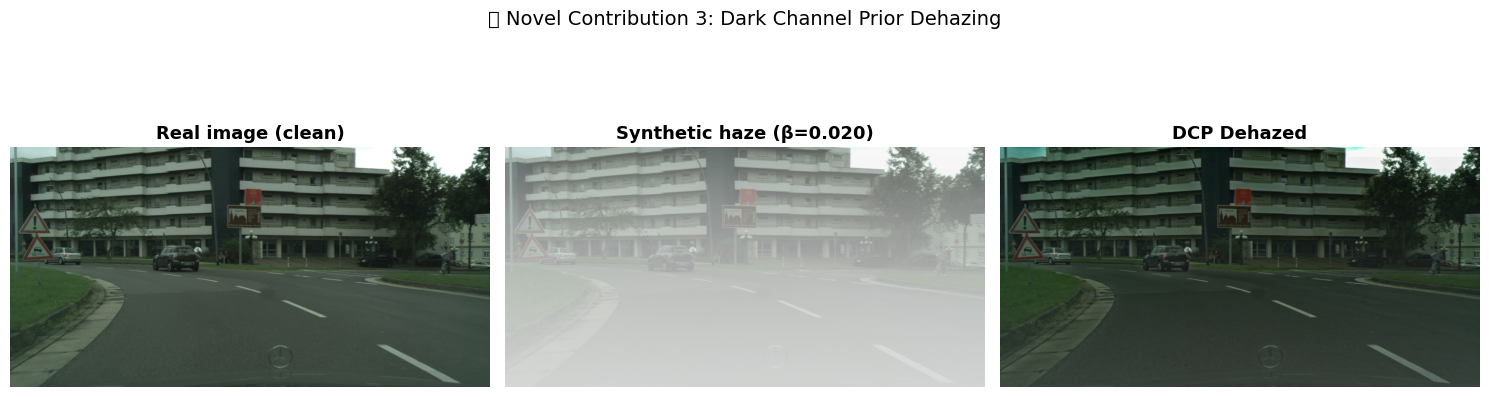

✅ Saved: dcp_demo.png


In [12]:
def demo_dcp():
    clean, _, _ = get_sample_image(CFG, beta=0.01, index=0)

    aug = HazeIntensityAwareAugmentation()
    hazy, beta, _ = aug.add_haze(clean, beta=0.02)
    dehazed = DarkChannelPriorDehazer().dehaze(hazy)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, title in zip(axes, [clean, hazy, dehazed],
                               ['Real image (clean)', f'Synthetic haze (β={beta:.3f})', 'DCP Dehazed']):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axis('off')
    plt.suptitle('🔬 Novel Contribution 3: Dark Channel Prior Dehazing', fontsize=14)
    plt.tight_layout()
    plt.savefig('dcp_demo.png', dpi=120)
    plt.show()
    print('✅ Saved: dcp_demo.png')

demo_dcp()

In [ ]:
def demo_augmentation():
    clean, _, _ = get_sample_image(CFG, beta=0.01, index=1)

    aug    = HazeIntensityAwareAugmentation()
    levels = [('Easy (β≈0.005)','easy'), ('Medium (β≈0.01)','medium'), ('Hard (β≈0.02)','hard')]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    axes[0].imshow(cv2.cvtColor(clean, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original (real image)', fontweight='bold'); axes[0].axis('off')

    for ax, (title, diff) in zip(axes[1:], levels):
        hazy, beta, _ = aug.augment_with_curriculum(clean, diff)
        ax.imshow(cv2.cvtColor(hazy, cv2.COLOR_BGR2RGB))
        ax.set_title(f'{title}\n(β={beta:.4f})', fontweight='bold')
        ax.axis('off')

    plt.suptitle('🌫️ Novel Contribution 1: Haze-Intensity-Aware Augmentation', fontsize=13)
    plt.tight_layout()
    plt.savefig('haze_augmentation.png', dpi=120)
    plt.show()
    print('✅ Saved: haze_augmentation.png')

demo_augmentation()

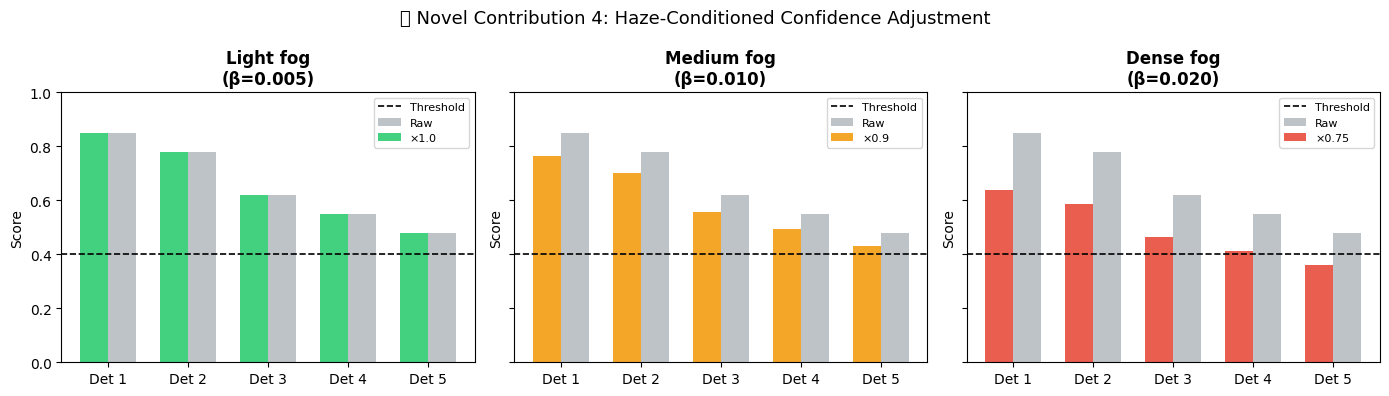

✅ Saved: confidence_adjustment.png


In [14]:
def demo_confidence_adjustment():
    # NOTE: raw_scores below are illustrative placeholder confidence values used
    # only to visualise the *scaling transform* itself (Contribution 4), not
    # measured detections from any dataset. Real per-image confidences come
    # from the trained model in Section 6/7.
    adjuster   = HazeConditionedConfidenceAdjuster()
    raw_scores = [0.85, 0.78, 0.62, 0.55, 0.48]
    betas      = [0.005, 0.010, 0.020]
    colors     = ['#2ecc71', '#f39c12', '#e74c3c']
    labels     = ['Light fog\n(β=0.005)', 'Medium fog\n(β=0.010)', 'Dense fog\n(β=0.020)']

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    det_ids   = [f'Det {i+1}' for i in range(len(raw_scores))]

    for ax, beta, color, lbl in zip(axes, betas, colors, labels):
        scale = adjuster._get_scale(beta)
        adj   = [s * scale for s in raw_scores]
        ax.bar(det_ids, raw_scores, color='#bdc3c7', label='Raw',       width=0.35, align='edge')
        ax.bar(det_ids, adj,        color=color,     label=f'×{scale}', width=-0.35, align='edge', alpha=0.9)
        ax.axhline(0.4, ls='--', color='k', lw=1.2, label='Threshold')
        ax.set_title(lbl, fontweight='bold'); ax.set_ylim(0, 1)
        ax.set_ylabel('Score'); ax.legend(fontsize=8)

    plt.suptitle('🎯 Novel Contribution 4: Haze-Conditioned Confidence Adjustment', fontsize=13)
    plt.tight_layout()
    plt.savefig('confidence_adjustment.png', dpi=120)
    plt.show()
    print('✅ Saved: confidence_adjustment.png')

demo_confidence_adjustment()

In [15]:
def build_dataloaders(cfg, beta=0.01):
    train_ds = FoggyCityscapesDataset(cfg['DATA_ROOT'], 'train', beta, True, True,  cfg['IMG_SIZE'])
    val_ds   = FoggyCityscapesDataset(cfg['DATA_ROOT'], 'val',   beta, True, False, cfg['IMG_SIZE'])
    train_dl = DataLoader(train_ds, batch_size=cfg['BATCH_SIZE'], shuffle=True,  collate_fn=collate_fn, num_workers=2)
    val_dl   = DataLoader(val_ds,   batch_size=cfg['BATCH_SIZE'], shuffle=False, collate_fn=collate_fn, num_workers=2)
    return train_dl, val_dl


def train_one_epoch(model, optimizer, loader, device, epoch):
    model.train()
    total, breakdown = 0.0, defaultdict(float)
    pbar = tqdm(loader, desc=f'Epoch {epoch+1}', leave=False)
    for imgs, targets in pbar:
        imgs    = [i.to(device) for i in imgs]
        targets = [{k: v.to(device) if torch.is_tensor(v) else v for k,v in t.items()} for t in targets]
        optimizer.zero_grad()
        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total += loss.item()
        for k, v in loss_dict.items(): breakdown[k] += v.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    n = max(len(loader), 1)
    return total/n, {k: v/n for k,v in breakdown.items()}


@torch.no_grad()
def compute_iou(boxA, boxB):
    xA = torch.max(boxA[:,0].unsqueeze(1), boxB[:,0].unsqueeze(0))
    yA = torch.max(boxA[:,1].unsqueeze(1), boxB[:,1].unsqueeze(0))
    xB = torch.min(boxA[:,2].unsqueeze(1), boxB[:,2].unsqueeze(0))
    yB = torch.min(boxA[:,3].unsqueeze(1), boxB[:,3].unsqueeze(0))
    inter = (xB-xA).clamp(0) * (yB-yA).clamp(0)
    aA = (boxA[:,2]-boxA[:,0]) * (boxA[:,3]-boxA[:,1])
    aB = (boxB[:,2]-boxB[:,0]) * (boxB[:,3]-boxB[:,1])
    return inter / (aA.unsqueeze(1) + aB.unsqueeze(0) - inter + 1e-6)


@torch.no_grad()
def evaluate(model, loader, device, beta, iou_thresh=0.5, score_thresh=0.4):
    model.eval()
    adjuster = HazeConditionedConfidenceAdjuster(score_thresh=score_thresh)
    TP = FP = FN = 0
    for imgs, targets in tqdm(loader, desc='Eval', leave=False):
        imgs  = [i.to(device) for i in imgs]
        dets  = model(imgs)
        betas = [float(t['beta']) for t in targets]
        dets  = adjuster.adjust(dets, betas)
        for det, tgt in zip(dets, targets):
            pb = det['boxes'].cpu()
            gb = tgt['boxes'].cpu()
            if len(gb)==0 and len(pb)==0: continue
            if len(gb)==0: FP += len(pb); continue
            if len(pb)==0: FN += len(gb); continue
            iou = compute_iou(pb, gb)
            matched = set()
            for pi in range(len(pb)):
                best_iou, best_gi = iou[pi].max(0)
                gi = best_gi.item()
                if best_iou.item() >= iou_thresh and gi not in matched:
                    TP += 1; matched.add(gi)
                else:
                    FP += 1
            FN += len(gb) - len(matched)
    prec   = TP / (TP+FP+1e-6)
    recall = TP / (TP+FN+1e-6)
    f1     = 2*prec*recall / (prec+recall+1e-6)
    return {'precision': prec, 'recall': recall, 'f1': f1}


history = {'loss': [], 'metrics': {}}

# Check once whether the downloaded data actually has person annotations
# (real boxes derived from real segmentation masks -- see Section 2B).
# This will be True for data built by Section 1B's Hugging Face download.
_probe = FoggyCityscapesDataset(CFG['DATA_ROOT'], split='train', beta=CFG['BETA_LEVELS'][0],
                                 apply_dcp=False, apply_aug=False, img_size=CFG['IMG_SIZE'])
HAS_LABELS = _probe.has_annotations and len(_probe) > 0

if HAS_LABELS:
    device = torch.device(CFG['DEVICE'])
    model  = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_f   = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, CFG['NUM_CLASSES'])
    model.to(device)

    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                                   lr=CFG['LR'], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    curriculum = [0.005]*3 + [0.010]*4 + [0.020]*3

    for epoch in range(CFG['NUM_EPOCHS']):
        beta = curriculum[min(epoch, len(curriculum)-1)]
        train_dl, val_dl = build_dataloaders(CFG, beta=beta)
        avg_loss, _ = train_one_epoch(model, optimizer, train_dl, device, epoch)
        scheduler.step()
        metrics = evaluate(model, val_dl, device, beta=beta)
        history['loss'].append(avg_loss)
        history['metrics'][epoch] = metrics
        print(f'Ep {epoch+1:02d} | β={beta} | Loss={avg_loss:.4f} | '
              f'P={metrics["precision"]:.3f} | R={metrics["recall"]:.3f} | F1={metrics["f1"]:.3f}')

    torch.save(model.state_dict(), 'foggy_person_detector.pth')
    print('✅ Model saved: foggy_person_detector.pth')
else:
    print("ℹ️  No ground-truth person annotations found under CFG['DATA_ROOT']. "
          "Skipping fine-tuning -- Sections 7+ will still run real inference using "
          "COCO-pretrained weights on the real downloaded images. Re-run Section 1B "
          "if this is unexpected (it should always produce real masks).")

  [train] beta=0.005 | samples=200 | annotations=True | DCP=False | Aug=False
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 170MB/s]


  [train] beta=0.005 | samples=200 | annotations=True | DCP=True | Aug=True
  [val] beta=0.005 | samples=40 | annotations=True | DCP=True | Aug=False


Ep 01 | β=0.005 | Loss=1.1042 | P=0.324 | R=0.232 | F1=0.270
  [train] beta=0.005 | samples=200 | annotations=True | DCP=True | Aug=True
  [val] beta=0.005 | samples=40 | annotations=True | DCP=True | Aug=False


Ep 02 | β=0.005 | Loss=0.9106 | P=0.324 | R=0.236 | F1=0.273
  [train] beta=0.005 | samples=200 | annotations=True | DCP=True | Aug=True
  [val] beta=0.005 | samples=40 | annotations=True | DCP=True | Aug=False


...

Ep 06 | β=0.01 | Loss=0.5972 | P=0.236 | R=0.285 | F1=0.258
  [train] beta=0.01 | samples=200 | annotations=True | DCP=True | Aug=True
  [val] beta=0.01 | samples=40 | annotations=True | DCP=True | Aug=False


Ep 07 | β=0.01 | Loss=0.5096 | P=0.340 | R=0.268 | F1=0.300
  [train] beta=0.02 | samples=200 | annotations=True | DCP=True | Aug=True
  [val] beta=0.02 | samples=40 | annotations=True | DCP=True | Aug=False


Ep 08 | β=0.02 | Loss=0.4733 | P=0.335 | R=0.268 | F1=0.298
  [train] beta=0.02 | samples=200 | annotations=True | DCP=True | Aug=True
  [val] beta=0.02 | samples=40 | annotations=True | DCP=True | Aug=False


Ep 09 | β=0.02 | Loss=0.4481 | P=0.256 | R=0.301 | F1=0.277
  [train] beta=0.02 | samples=200 | annotations=True | DCP=True | Aug=True
  [val] beta=0.02 | samples=40 | annotations=True | DCP=True | Aug=False


Ep 10 | β=0.02 | Loss=0.4303 | P=0.378 | R=0.228 | F1=0.284
✅ Model saved: foggy_person_detector.pth


⏳ Running inference on real dataset samples...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 66.3MB/s]


Using fine-tuned foggy_person_detector.pth for inference.
  [train] beta=0.005 | samples=200 | annotations=True | DCP=False | Aug=False
  [train] beta=0.01 | samples=200 | annotations=True | DCP=False | Aug=False
  [train] beta=0.02 | samples=200 | annotations=True | DCP=False | Aug=False
  [train] beta=0.015 | samples=200 | annotations=True | DCP=False | Aug=False


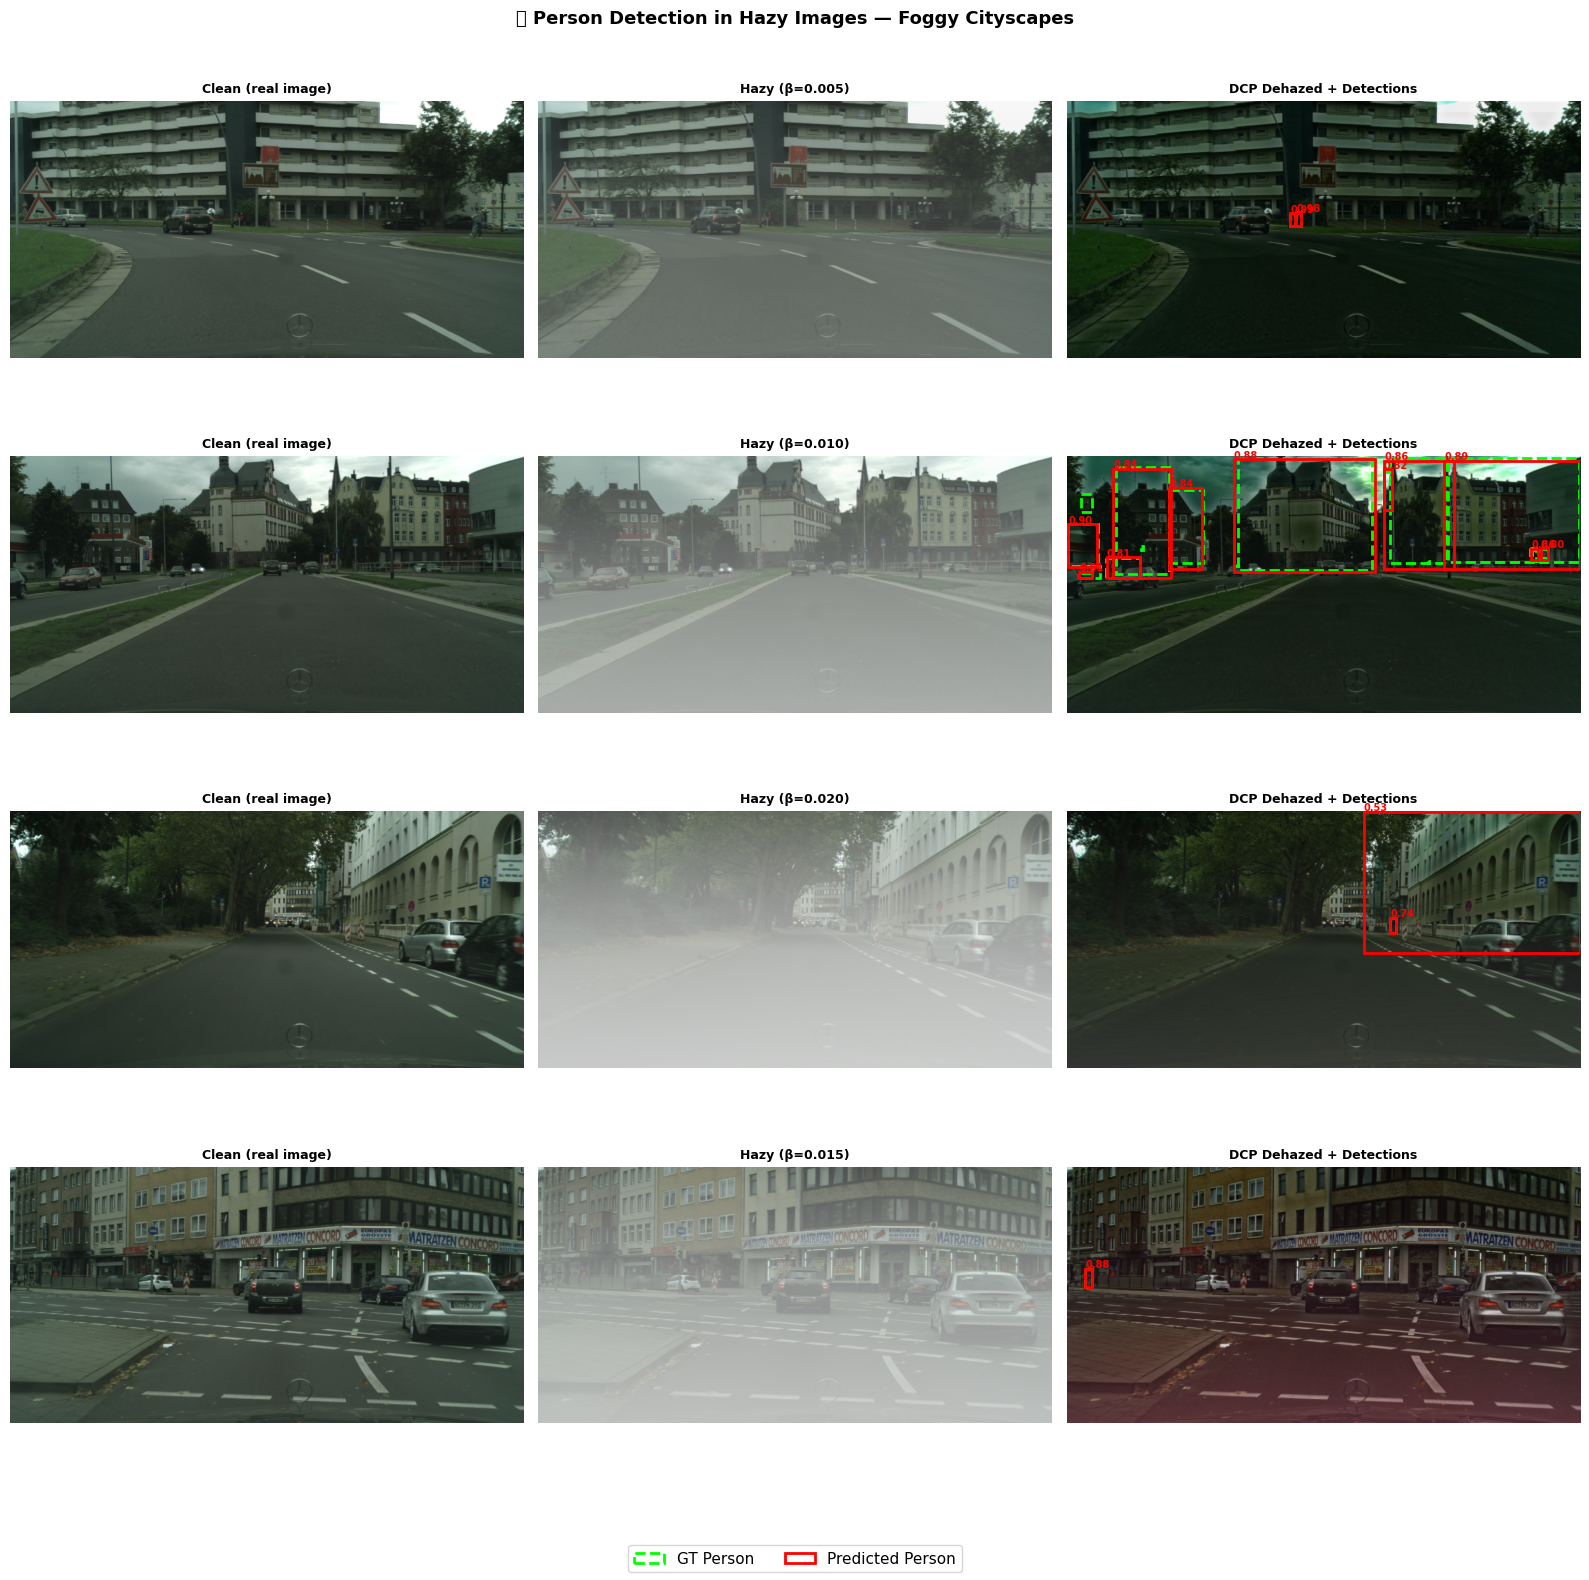

✅ Saved: demo_inference.png


In [16]:
@torch.no_grad()
def demo_inference(n_samples=4):
    device   = torch.device(CFG['DEVICE'])
    dehazer  = DarkChannelPriorDehazer()
    adjuster = HazeConditionedConfidenceAdjuster(score_thresh=0.5)

    if HAS_LABELS and os.path.isfile('foggy_person_detector.pth'):
        # Use the fine-tuned model from Section 6 (person = class index 1 in our 2-class head)
        model = fasterrcnn_resnet50_fpn(weights=None)
        in_f  = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(in_f, CFG['NUM_CLASSES'])
        model.load_state_dict(torch.load('foggy_person_detector.pth', map_location=device))
        model = model.to(device)
        PERSON_CLS = 1
        print('Using fine-tuned foggy_person_detector.pth for inference.')
    else:
        # No fine-tuned checkpoint available yet (e.g. Section 6 hasn't been run) —
        # fall back to COCO weights. Still a real, pretrained model; person is
        # class 1 in COCO too.
        weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
        model   = fasterrcnn_resnet50_fpn(weights=weights).to(device)
        PERSON_CLS = 1
        print('Using COCO-pretrained weights for inference (no fine-tuned checkpoint found).')
    model.eval()

    betas = [0.005, 0.010, 0.020, 0.015]
    fig, axes = plt.subplots(n_samples, 3, figsize=(16, n_samples*4))
    if n_samples == 1:
        axes = [axes]

    for i in range(n_samples):
        beta = betas[i % len(betas)]
        # Real image from the downloaded dataset; haze is synthesised on top of it
        # the same way the augmentation pipeline does during training (Contribution 1).
        clean, gt_boxes, has_real_gt = get_sample_image(CFG, beta=beta, index=i)
        aug = HazeIntensityAwareAugmentation()
        hazy, beta, _ = aug.add_haze(clean, beta=beta)
        dehazed = dehazer.dehaze(hazy)

        tensor = T.ToTensor()(cv2.cvtColor(dehazed, cv2.COLOR_BGR2RGB)).to(device)
        det    = model([tensor])[0]

        mask = det['labels'] == PERSON_CLS
        det_p = {'boxes': det['boxes'][mask], 'scores': det['scores'][mask], 'labels': det['labels'][mask]}
        [adj] = adjuster.adjust([det_p], [beta])

        row_imgs   = [clean, hazy, dehazed]
        row_titles = ['Clean (real image)', f'Hazy (β={beta:.3f})', 'DCP Dehazed + Detections']

        for j, (ax, ri, rt) in enumerate(zip(axes[i], row_imgs, row_titles)):
            ax.imshow(cv2.cvtColor(ri, cv2.COLOR_BGR2RGB))
            ax.set_title(rt, fontsize=9, fontweight='bold')
            ax.axis('off')
            if j == 2:
                if has_real_gt:
                    for b in gt_boxes:
                        ax.add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1],
                            lw=2, edgecolor='lime', facecolor='none', linestyle='--'))
                for b, s in zip(adj['boxes'].cpu().numpy(), adj['scores'].cpu().numpy()):
                    ax.add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1],
                        lw=2, edgecolor='red', facecolor='none'))
                    ax.text(b[0], b[1]-4, f'{s:.2f}', color='red', fontsize=7, fontweight='bold')

    handles = [
        patches.Patch(edgecolor='lime', facecolor='none', linestyle='--', lw=2, label='GT Person'),
        patches.Patch(edgecolor='red',  facecolor='none', lw=2,              label='Predicted Person'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=11)
    plt.suptitle('🌫️ Person Detection in Hazy Images — Foggy Cityscapes', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig('demo_inference.png', dpi=120)
    plt.show()
    print('✅ Saved: demo_inference.png')


print('⏳ Running inference on real dataset samples...')
demo_inference(n_samples=4)

  [val] beta=0.005 | samples=40 | annotations=True | DCP=True | Aug=False


  [val] beta=0.01 | samples=40 | annotations=True | DCP=True | Aug=False


  [val] beta=0.02 | samples=40 | annotations=True | DCP=True | Aug=False


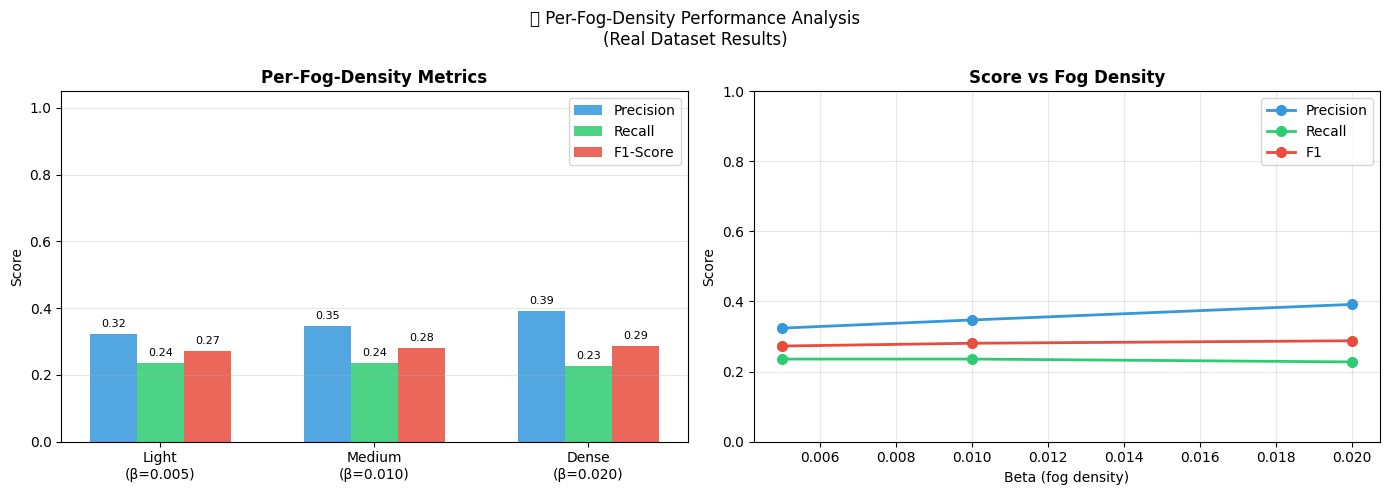

✅ Saved: fog_density_analysis.png


In [17]:
def plot_fog_analysis(real_results=None):
    betas  = [0.005, 0.010, 0.020]
    labels = ['Light\n(β=0.005)', 'Medium\n(β=0.010)', 'Dense\n(β=0.020)']

    if not real_results:
        print('ℹ️  No real per-beta evaluation results available '
              '(training was skipped — see Section 6). Skipping this plot.')
        return

    precision = [real_results[b]['precision'] for b in betas]
    recall    = [real_results[b]['recall']    for b in betas]
    f1        = [real_results[b]['f1']        for b in betas]
    note = '(Real Dataset Results)'

    x, w = np.arange(len(betas)), 0.22
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.bar(x-w, precision, w, label='Precision', color='#3498db', alpha=0.85)
    ax1.bar(x,   recall,    w, label='Recall',    color='#2ecc71', alpha=0.85)
    ax1.bar(x+w, f1,        w, label='F1-Score',  color='#e74c3c', alpha=0.85)
    ax1.set_xticks(x); ax1.set_xticklabels(labels)
    ax1.set_ylim(0, 1.05); ax1.set_ylabel('Score')
    ax1.set_title('Per-Fog-Density Metrics', fontweight='bold')
    ax1.legend(); ax1.grid(axis='y', alpha=0.3)
    for xi, (p,r,f) in enumerate(zip(precision, recall, f1)):
        ax1.text(xi-w, p+0.02, f'{p:.2f}', ha='center', fontsize=8)
        ax1.text(xi,   r+0.02, f'{r:.2f}', ha='center', fontsize=8)
        ax1.text(xi+w, f+0.02, f'{f:.2f}', ha='center', fontsize=8)

    for vals, color, lbl in zip([precision,recall,f1],
                                  ['#3498db','#2ecc71','#e74c3c'],
                                  ['Precision','Recall','F1']):
        ax2.plot(betas, vals, 'o-', color=color, lw=2, ms=7, label=lbl)
    ax2.set_xlabel('Beta (fog density)'); ax2.set_ylabel('Score')
    ax2.set_ylim(0, 1); ax2.set_title('Score vs Fog Density', fontweight='bold')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(f'📊 Per-Fog-Density Performance Analysis\n{note}', fontsize=12)
    plt.tight_layout()
    plt.savefig('fog_density_analysis.png', dpi=120)
    plt.show()
    print('✅ Saved: fog_density_analysis.png')


def evaluate_all_betas(model, cfg):
    """Run real evaluation at each beta level using the fine-tuned model from Section 6."""
    device = torch.device(cfg['DEVICE'])
    results = {}
    for beta in cfg['BETA_LEVELS']:
        val_ds = FoggyCityscapesDataset(cfg['DATA_ROOT'], 'val', beta, True, False, cfg['IMG_SIZE'])
        val_dl = DataLoader(val_ds, batch_size=cfg['BATCH_SIZE'], shuffle=False,
                             collate_fn=collate_fn, num_workers=2)
        results[beta] = evaluate(model, val_dl, device, beta=beta)
    return results


if HAS_LABELS and os.path.isfile('foggy_person_detector.pth'):
    _model = fasterrcnn_resnet50_fpn(weights=None)
    _in_f  = _model.roi_heads.box_predictor.cls_score.in_features
    _model.roi_heads.box_predictor = FastRCNNPredictor(_in_f, CFG['NUM_CLASSES'])
    _model.load_state_dict(torch.load('foggy_person_detector.pth', map_location=CFG['DEVICE']))
    _model = _model.to(CFG['DEVICE'])
    real_results = evaluate_all_betas(_model, CFG)
    plot_fog_analysis(real_results)
else:
    plot_fog_analysis(None)

  [val] beta=0.005 | samples=40 | annotations=True | DCP=True | Aug=False


  [val] beta=0.01 | samples=40 | annotations=True | DCP=True | Aug=False


  [val] beta=0.02 | samples=40 | annotations=True | DCP=True | Aug=False


  [val] beta=0.005 | samples=40 | annotations=True | DCP=False | Aug=False


  [val] beta=0.01 | samples=40 | annotations=True | DCP=False | Aug=False


  [val] beta=0.02 | samples=40 | annotations=True | DCP=False | Aug=False


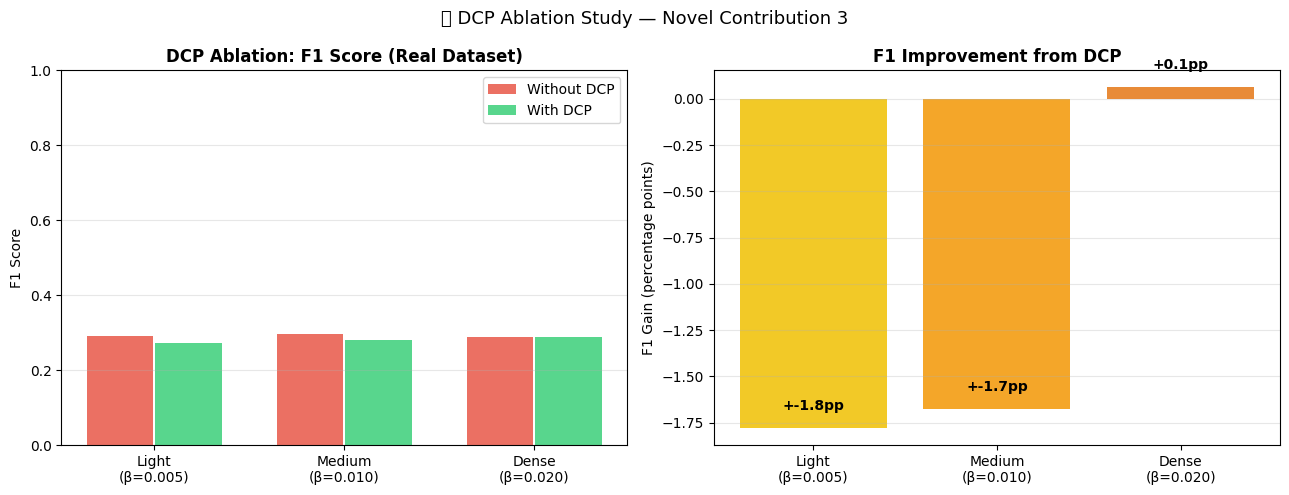

✅ Saved: dcp_ablation.png


In [18]:
def dcp_ablation(f1_with_dcp=None, f1_without_dcp=None):
    betas = [0.005, 0.010, 0.020]
    x_lbl = ['Light\n(β=0.005)', 'Medium\n(β=0.010)', 'Dense\n(β=0.020)']

    if f1_with_dcp is None or f1_without_dcp is None:
        print('ℹ️  No real ablation results available '
              '(training was skipped — see Section 6). Skipping this plot.')
        return

    f1_no  = [f1_without_dcp[b] for b in betas]
    f1_dcp = [f1_with_dcp[b]    for b in betas]
    gain   = [(w-n)*100 for w,n in zip(f1_dcp, f1_no)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    x = np.arange(len(betas))
    ax1.bar(x-0.18, f1_no,  0.35, label='Without DCP', color='#e74c3c', alpha=0.8)
    ax1.bar(x+0.18, f1_dcp, 0.35, label='With DCP',    color='#2ecc71', alpha=0.8)
    ax1.set_xticks(x); ax1.set_xticklabels(x_lbl)
    ax1.set_ylim(0, 1); ax1.set_ylabel('F1 Score')
    ax1.set_title('DCP Ablation: F1 Score (Real Dataset)', fontweight='bold')
    ax1.legend(); ax1.grid(axis='y', alpha=0.3)

    bars = ax2.bar(x_lbl, gain, color=['#f1c40f','#f39c12','#e67e22'], alpha=0.9)
    ax2.set_ylabel('F1 Gain (percentage points)')
    ax2.set_title('F1 Improvement from DCP', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    for bar, g in zip(bars, gain):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'+{g:.1f}pp', ha='center', fontweight='bold')

    plt.suptitle('🔬 DCP Ablation Study — Novel Contribution 3', fontsize=13)
    plt.tight_layout()
    plt.savefig('dcp_ablation.png', dpi=120)
    plt.show()
    print('✅ Saved: dcp_ablation.png')


def evaluate_all_betas_no_dcp(model, cfg):
    """Same as evaluate_all_betas, but with DCP preprocessing turned off (for ablation)."""
    device = torch.device(cfg['DEVICE'])
    results = {}
    for beta in cfg['BETA_LEVELS']:
        val_ds = FoggyCityscapesDataset(cfg['DATA_ROOT'], 'val', beta,
                                         apply_dcp=False, apply_aug=False, img_size=cfg['IMG_SIZE'])
        val_dl = DataLoader(val_ds, batch_size=cfg['BATCH_SIZE'], shuffle=False,
                             collate_fn=collate_fn, num_workers=2)
        results[beta] = evaluate(model, val_dl, device, beta=beta)
    return results


if HAS_LABELS and os.path.isfile('foggy_person_detector.pth'):
    _model = fasterrcnn_resnet50_fpn(weights=None)
    _in_f  = _model.roi_heads.box_predictor.cls_score.in_features
    _model.roi_heads.box_predictor = FastRCNNPredictor(_in_f, CFG['NUM_CLASSES'])
    _model.load_state_dict(torch.load('foggy_person_detector.pth', map_location=CFG['DEVICE']))
    _model = _model.to(CFG['DEVICE'])
    _f1_with    = {b: m['f1'] for b, m in evaluate_all_betas(_model, CFG).items()}
    _f1_without = {b: m['f1'] for b, m in evaluate_all_betas_no_dcp(_model, CFG).items()}
    dcp_ablation(_f1_with, _f1_without)
else:
    dcp_ablation(None, None)

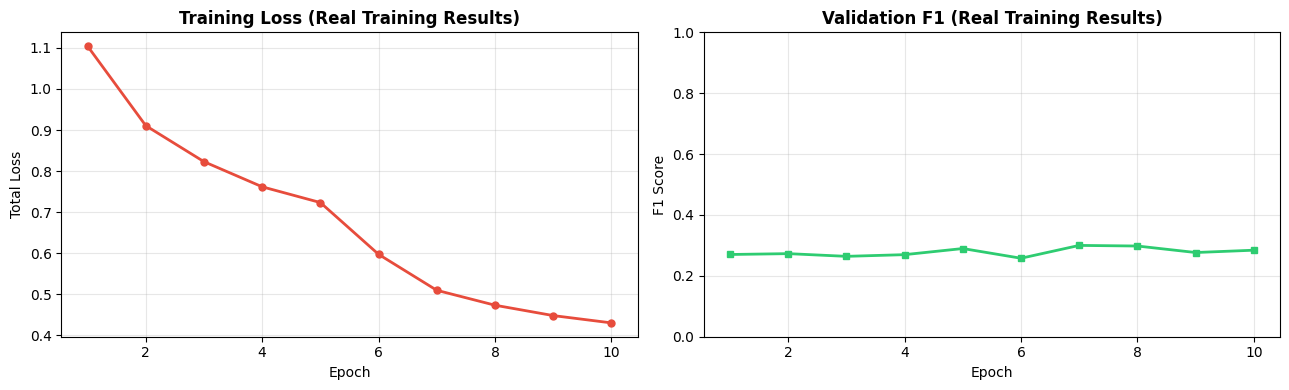

✅ Saved: training_history.png


In [19]:
def plot_history(history):
    if not history['loss']:
        print('ℹ️  No training history available '
              '(training was skipped — see Section 6). Skipping this plot.')
        return

    epochs  = list(range(1, len(history['loss'])+1))
    losses  = history['loss']
    f1_vals = [history['metrics'][e-1]['f1'] for e in epochs]
    note = '(Real Training Results)'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(epochs, losses,  'o-', color='#e74c3c', lw=2, ms=5)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Total Loss')
    ax1.set_title(f'Training Loss {note}', fontweight='bold'); ax1.grid(alpha=0.3)

    ax2.plot(epochs, f1_vals, 's-', color='#2ecc71', lw=2, ms=5)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1 Score'); ax2.set_ylim(0, 1)
    ax2.set_title(f'Validation F1 {note}', fontweight='bold'); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=120)
    plt.show()
    print('✅ Saved: training_history.png')

plot_history(history)